<a href="https://colab.research.google.com/github/SAMAD-KHAN03/ml/blob/master/algorithms/Regularization%26Hyperparametres/Regularzation%26Hyperparamtres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.78285e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.390e+02, tolerance: 1.772e-01
  model = cd_fast.enet_coordinate_descent(


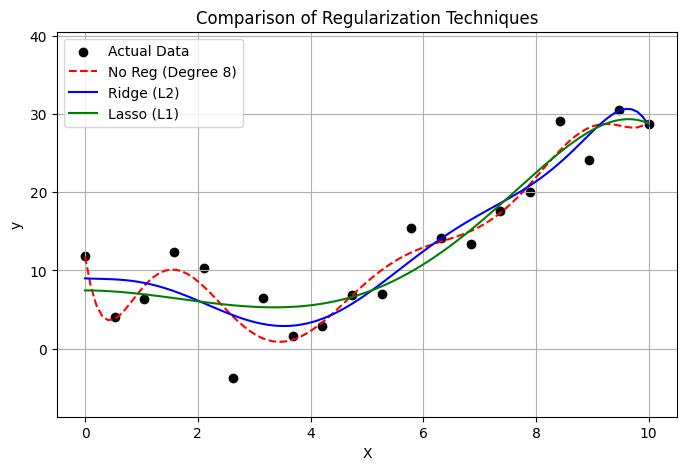

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline

# ------------------------------------
# # 1) Create sample data (with noise)
# ------------------------------------
np.random.seed(0)

X = np.linspace(0, 10, 20).reshape(-1, 1)
y = 0.5 * X**2 - 2*X + 3 + np.random.randn(20, 1)*5  # Non-linear data

# ------------------------------------
# # 2) Make polynomial features
# ------------------------------------
degree = 8  # high degree -> risk of overfitting

# # Models
model_no_reg = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model_ridge = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=0.5))  # L2
model_lasso = make_pipeline(PolynomialFeatures(degree), Lasso(alpha=0.5))  # L1

# # Train models
model_no_reg.fit(X, y)
model_ridge.fit(X, y)
model_lasso.fit(X, y)

# ------------------------------------
# # 3) Plot results
# ------------------------------------
X_test = np.linspace(0, 10, 100).reshape(-1, 1)

# Predict using the trained models
y_pred_no_reg = model_no_reg.predict(X_test)
y_pred_ridge = model_ridge.predict(X_test)
y_pred_lasso = model_lasso.predict(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='black', label="Actual Data")

# Plotting the regression curves
plt.plot(X_test, y_pred_no_reg, label=f"No Reg (Degree {degree})", color='red', linestyle='--')
plt.plot(X_test, y_pred_ridge, label="Ridge (L2)", color='blue')
plt.plot(X_test, y_pred_lasso, label="Lasso (L1)", color='green')

plt.title("Comparison of Regularization Techniques")
plt.xlabel("X")
plt.ylabel("y")
plt.ylim(min(y) - 5, max(y) + 10) # Keeping the view focused
plt.legend()
plt.grid(True)
plt.show()